# **Cellpose on 2um Tiny Mouse VisiumHD image**

[Cellpose Paper](https://www.nature.com/articles/s41592-020-01018-x)

### Cellpose method:
- Cellpose converts tissue images into "vector fields", such that each pixel points towards the center of its cell. 
- Thus, pixels that all "flow" towards the same convergence basin becomes one labeled mask/ cell



In [60]:
import pyhere as here

Image shape: (5394, 6000, 3)


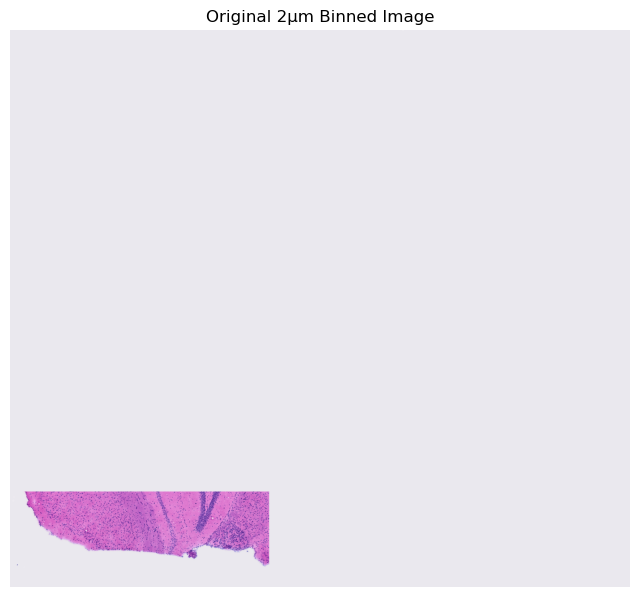

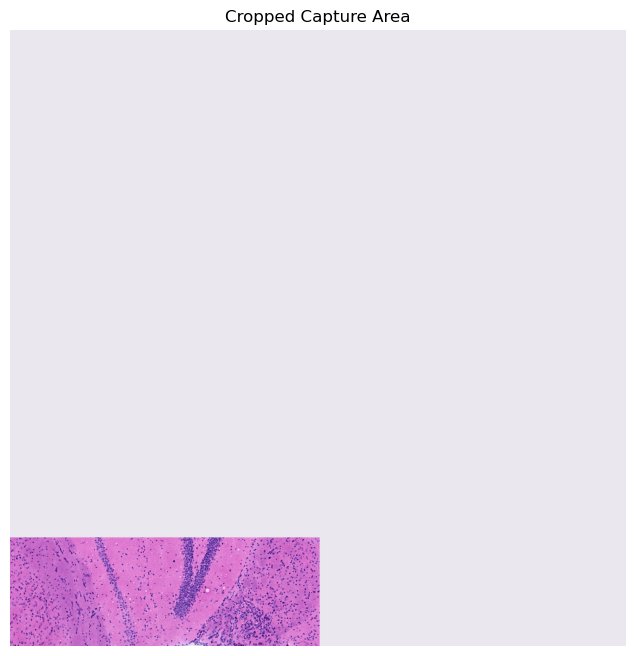

2026-02-12 16:14:47,839 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-02-12 16:14:47,844 [INFO] >>>> using CPU
2026-02-12 16:14:47,845 [INFO] >>>> using CPU
2026-02-12 16:14:49,151 [INFO] >>>> loading model /Users/jmakings/.cellpose/models/cpsam
2026-02-12 16:14:50,162 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-12 16:14:50,183 [INFO] processing image with (3000, 3000) HW, and 3 channels


ValueError: not enough values to unpack (expected 4, got 3)

In [ ]:
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.models import CellposeModel

# ——————————————————————————————
# 1) Load the 2µm binned Tiny Mouse HD image
image_path = here.here("data/visiumhd_tinymouse/binned_outputs/square_002um/spatial","tissue_hires_image.png")
img = imread(image_path)
print("Image shape:", img.shape)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Original 2µm Binned Image")
plt.show()

# ——————————————————————————————
# 2) Crop the image (replace bbox with your capture area)
# bbox format: {'x': [x_min, x_max], 'y': [y_min, y_max]}
bbox = {'x': [1000, 4000], 'y': [2000, 5000]}  # example coordinates in pixels

cropped_img = img[bbox['y'][0]:bbox['y'][1], bbox['x'][0]:bbox['x'][1]]

plt.figure(figsize=(8, 8))
plt.imshow(cropped_img)
plt.axis("off")
plt.title("Cropped Capture Area")
plt.show()

# ——————————————————————————————
# 3) Run Cellpose segmentation
model = CellposeModel(model_type='nuclei', 
                        gpu=False, 
                       )
masks, flows, styles = model.eval(cropped_img, diameter=None, channels=[0,0])

plt.figure(figsize=(8,8))
plt.imshow(cropped_img)
plt.imshow(masks, alpha=0.4)
plt.axis("off")
plt.title("Cellpose Segmentation")
plt.show()


# ——————————————————————————————
# 4) Optional: map segmentation to a lower-res spot grid
# If you want, you can create a fake “spot grid” like 50x50 pixels per spot:
spot_size = 50
spots_y = cropped_img.shape[0] // spot_size
spots_x = cropped_img.shape[1] // spot_size

spot_masks = np.zeros((spots_y, spots_x), dtype=int)

for i in range(spots_y):
    for j in range(spots_x):
        patch = masks[i*spot_size:(i+1)*spot_size, j*spot_size:(j+1)*spot_size]
        spot_masks[i, j] = np.sum(patch > 0)  # count of nuclei per spot

print("Spot-level segmentation counts shape:", spot_masks.shape)
